# Atividade 1 — Preparação e descrição dos dados

**Projeto de Extensão AACD — Prevenção de Quedas**

Base: `base_quedas_AACD_anonimizada.xlsx`, abas `60+` (idosos, foco do estudo) e
`60-` (adultos 18–59, comparação).

Entregas desta atividade: base consolidada, tabela de qualidade, tabela de decisões
de limpeza, descrição do histórico de quedas, cálculo do custo de dupla tarefa e
lista de dúvidas para a equipe da AACD.

Dados reais de saúde protegidos pela LGPD. Apenas resultados agregados saem deste
notebook.

## 1. Leitura e consolidação

In [1]:
import os
import re
import warnings
from collections import Counter, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 180)

PLANILHA = "base_quedas_AACD_anonimizada.xlsx"
ABAS = ["60+", "60-"]

AZUL, LARANJA = "#2a78d6", "#eb6834"
AZUIS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]
VERMELHO, CINZA = "#e34948", "#c9c7c0"
SUPERFICIE, TINTA, TINTA2 = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.bbox": "tight",
    "axes.edgecolor": TINTA2, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
    "font.size": 10, "figure.dpi": 110,
})

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [2]:
wb = openpyxl.load_workbook(PLANILHA, data_only=True)

for nome in ABAS:
    aba = wb[nome]
    alturas = Counter(f.max_row - f.min_row + 1 for f in aba.merged_cells.ranges)
    print(f"{nome}: {aba.max_row} linhas, {aba.max_column} colunas, "
          f"{len(aba.merged_cells.ranges)} células mescladas, alturas {dict(alturas)}")

60+: 333 linhas, 27 colunas, 3839 células mescladas, alturas {2: 3839}
60-: 232 linhas, 27 colunas, 2769 células mescladas, alturas {2: 2769}


In [3]:
def normaliza(valor):
    if valor is None:
        return None
    if isinstance(valor, str):
        texto = re.sub(r"\s+", " ", valor).strip()
        return texto or None
    return valor


def le_aba(nome_aba):
    aba = wb[nome_aba]
    colunas = [re.sub(r"\s+", " ", str(aba.cell(1, c).value)).strip()
               for c in range(1, aba.max_column + 1)]
    registros = []
    for linha in range(2, aba.max_row + 1, 2):
        registro = OrderedDict()
        for c, coluna in enumerate(colunas, start=1):
            primeira = normaliza(aba.cell(linha, c).value)
            segunda = (normaliza(aba.cell(linha + 1, c).value)
                       if linha + 1 <= aba.max_row else None)
            registro[coluna] = primeira if primeira is not None else segunda
        registro["grupo_origem"] = nome_aba
        registros.append(registro)
    return colunas, pd.DataFrame(registros)


COLUNAS_ORIGINAIS, _ = le_aba(ABAS[0])
partes = [le_aba(nome)[1] for nome in ABAS]
base = pd.concat(partes, ignore_index=True)

print(f"Participantes: {len(base)}")
print(base.groupby("grupo_origem", sort=False).size().to_frame("participantes").to_string())

Participantes: 282
              participantes
grupo_origem               
60+                     166
60-                     116


In [4]:
base["chave"] = base["grupo_origem"] + "_" + base["ID"].astype(int).astype(str).str.zfill(3)

assert base["chave"].is_unique, "chave duplicada"
assert len(base) == 282, "número de participantes diferente do esperado"
for nome in ABAS:
    ids = base.loc[base["grupo_origem"] == nome, "ID"].astype(int)
    assert ids.duplicated().sum() == 0
    assert sorted(ids) == list(range(ids.min(), ids.max() + 1))

print("Uma linha por participante, chave única e IDs contíguos em cada aba.")
base[["chave", "grupo_origem", "ID", "Sexo", "Idade", "Clínica/Dx"]].head()

Uma linha por participante, chave única e IDs contíguos em cada aba.


,chave,grupo_origem,ID,Sexo,Idade,Clínica/Dx
0,60+_001,60+,1,M,68,LEA
1,60+_002,60+,2,M,72,AMP
2,60+_003,60+,3,F,77,Parkison
3,60+_004,60+,4,M,62,AMP
4,60+_005,60+,5,F,62,DNM


## 2. Qualidade e limpeza

### 2.1 Tabela de qualidade

In [5]:
MARCADORES = {"NA", "N/A", "na", "n/a", ".", "-", "?", "k", "o", "AMP"}


def e_numero(valor):
    return bool(re.fullmatch(r"-?\d+([.,]\d+)?", str(valor).strip()))


def tabela_qualidade(df, colunas):
    linhas = []
    for coluna in colunas:
        serie = df[coluna]
        preenchidos = serie.dropna()
        marcadores = Counter(str(v) for v in preenchidos
                             if isinstance(v, str) and str(v).strip() in MARCADORES)
        texto_nao_numerico = sum(1 for v in preenchidos
                                 if isinstance(v, str) and not e_numero(v)
                                 and str(v).strip() not in MARCADORES)
        tipos = Counter(type(v).__name__ for v in preenchidos)
        linhas.append({
            "coluna": coluna,
            "preenchidos": len(preenchidos),
            "vazios": int(serie.isna().sum()),
            "% vazio": round(serie.isna().mean() * 100, 1),
            "distintos": int(preenchidos.nunique()),
            "tipos no conteúdo": len(tipos),
            "marcadores de ausência": sum(marcadores.values()),
            "quais marcadores": ", ".join(f"{k}({v})" for k, v in marcadores.most_common(3)),
            "textos livres": texto_nao_numerico,
        })
    return pd.DataFrame(linhas)


qualidade = tabela_qualidade(base, COLUNAS_ORIGINAIS)
qualidade.sort_values(["% vazio", "tipos no conteúdo"], ascending=False)

,coluna,preenchidos,vazios,% vazio,distintos,tipos no conteúdo,marcadores de ausência,quais marcadores,textos livres
26,Custo dupla tarefa,0,282,100.0,0,0,0,,0
19,Braço E,30,252,89.4,16,3,5,NA(5),0
18,Braço D,33,249,88.3,18,1,0,,0
10,Cognição (10-CS),66,216,76.6,11,1,0,,0
4,Diagnóstico Funcional,68,214,75.9,14,1,0,,68
9,Cognição (MOCA),76,206,73.0,21,1,0,,0
13,Sentar/levantar 30s,122,160,56.7,19,2,10,NA(10),0
14,Ponte,163,119,42.2,29,2,7,NA(7),0
21,Aditamento 10m,230,52,18.4,25,1,0,,230
17,Panturrilha E,244,38,13.5,42,3,82,NA(82),0


In [6]:
print("Colunas com mais de um tipo de dado no conteúdo:")
print(qualidade.loc[qualidade["tipos no conteúdo"] > 1,
                    ["coluna", "tipos no conteúdo", "quais marcadores"]].to_string(index=False))
print()
print(f"Colunas totalmente vazias: "
      f"{qualidade.loc[qualidade['% vazio'] == 100, 'coluna'].tolist()}")
print(f"Colunas com marcadores de ausência escritos à mão: "
      f"{int((qualidade['marcadores de ausência'] > 0).sum())} de {len(qualidade)}")

Colunas com mais de um tipo de dado no conteúdo:
              coluna  tipos no conteúdo quais marcadores
               Idade                  2             k(1)
   Nº quedas ao chão                  3                 
    Queda último mês                  2                 
 Sentar/levantar 30s                  2           NA(10)
               Ponte                  2            NA(7)
         Dinamômetro                  3            NA(1)
       Panturrilha D                  3   NA(71), AMP(2)
       Panturrilha E                  3           NA(82)
             Braço E                  3            NA(5)
           10 metros                  3           NA(43)
      CIF equilíbrio                  2      NA(2), o(1)
   Reação (blazepod)                  3            NA(4)
Reação (blazepod) DT                  2           NA(11)

Colunas totalmente vazias: ['Custo dupla tarefa']
Colunas com marcadores de ausência escritos à mão: 15 de 27


### 2.2 Tabela de decisões de limpeza

In [7]:
def conta(condicao):
    return int(condicao.sum())


def para_numero(valor):
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return np.nan
    if isinstance(valor, (int, float)):
        return float(valor)
    texto = str(valor).strip()
    if texto in MARCADORES:
        return np.nan
    limpo = texto.replace(",", ".").lstrip("´`'").rstrip("?")
    try:
        return float(limpo)
    except ValueError:
        return np.nan


n_idade_duvida = conta(base["Idade"].astype(str).str.contains(r"\?", na=False))
n_quedas_apostrofo = conta(base["Nº quedas ao chão"].astype(str).str.contains("´", na=False))
n_mes_numerico = conta(base["Queda último mês"].apply(
    lambda v: isinstance(v, (int, float)) and not pd.isna(v)))
n_ponto = conta((base["Suporte social (terapêutico)"].astype(str) == ".") |
                (base["Suporte social (domiciliar)"].astype(str) == "."))
n_na_pant = conta(base["Panturrilha D"].astype(str).isin(["NA", "AMP"]))
n_na_10m = conta(base["10 metros"].astype(str) == "NA")
n_sexo_2a_linha = 0
for nome in ABAS:
    aba = wb[nome]
    for linha in range(2, aba.max_row + 1, 2):
        if aba.cell(linha, 2).value is None and aba.cell(linha + 1, 2).value is not None:
            n_sexo_2a_linha += 1

n_mescladas = sum(len(wb[nome].merged_cells.ranges) for nome in ABAS)

DECISOES = [
    (f"Estrutura: cada participante ocupa 2 linhas, com {n_mescladas} células mescladas",
     "Achatar o bloco de 2 linhas tomando o primeiro valor não vazio do par",
     "Verificado que as duas linhas nunca se contradizem nos 282 blocos. "
     f"Em {n_sexo_2a_linha} participantes o Sexo estava apenas na 2ª linha",
     282),
    ("ID se repete entre as abas (1–166 e 1–116)",
     "Criar a coluna chave = grupo_origem + ID com 3 dígitos",
     "ID sozinho não identifica o participante na base consolidada",
     282),
    ("'NA' escrito à mão em testes não realizados",
     "Converter para valor ausente, mantendo registro de que o teste não foi feito",
     "'NA' é texto e impede qualquer cálculo numérico na coluna",
     n_na_pant + n_na_10m),
    ("'AMP' na circunferência da panturrilha",
     "Converter para ausente e tratar como ausência estrutural",
     "Membro amputado: não existe panturrilha para medir, então não cabe imputação",
     conta(base["Panturrilha D"].astype(str) == "AMP")),
    ("Idade anotada com '?' (ex. '59?')",
     "Aproveitar o número e registrar o caso na lista de dúvidas",
     "O '?' indica incerteza do avaliador, não um valor diferente",
     n_idade_duvida),
    ("Idade preenchida com texto ('k')",
     "Converter para ausente e levar à AACD",
     "Tecla digitada por engano; não há como inferir o valor",
     1),
    ("Nº de quedas gravado como '´2' (apóstrofo do Excel)",
     "Remover o apóstrofo e converter para número",
     "O apóstrofo é artefato de digitação no Excel, não parte do valor",
     n_quedas_apostrofo),
    ("'Queda último mês' gravada como número (0 e 2) em vez de sim/não",
     "Interpretar 0 como 'não' e valores ≥1 como 'sim', sinalizando os casos",
     "São os IDs 22–29, consecutivos, indicando convenção própria de um avaliador. "
     "A interpretação fica registrada para ser confirmada",
     n_mes_numerico),
    ("Suporte social preenchido com '.'",
     "Converter para ausente, sem supor significado",
     "Não se sabe se '.' significa sem dado ou sem acompanhante",
     n_ponto),
    ("Coluna 'Custo dupla tarefa' inteiramente vazia",
     "Calcular a partir das duas medidas de reação (seção 4.1)",
     "A coluna estava prevista na planilha mas nunca foi preenchida",
     282),
    ("'Parkison' e 'Parkinson' como diagnósticos separados",
     "Padronizar a grafia apenas para contagem; manter a coluna original intacta",
     "É a mesma doença contada duas vezes, o que distorce a descrição da população",
     conta(base["Clínica/Dx"].astype(str).str.contains("Parki", na=False))),
    ("'Sentada' e 'Sentado' na posição de equilíbrio",
     "Unificar a grafia para contagem; manter a coluna original intacta",
     "A aba 60- usou o feminino; é a mesma categoria",
     conta(base["Posição equilíbrio"].astype(str).str.lower().str.startswith("sentad"))),
]

decisoes = pd.DataFrame(DECISOES, columns=[
    "o que foi encontrado", "decisão tomada", "justificativa", "casos afetados"])
decisoes

,o que foi encontrado,decisão tomada,justificativa,casos afetados
0,"Estrutura: cada participante ocupa 2 linhas, com 6608 células mesc...",Achatar o bloco de 2 linhas tomando o primeiro valor não vazio do par,Verificado que as duas linhas nunca se contradizem nos 282 blocos....,282
1,ID se repete entre as abas (1–166 e 1–116),Criar a coluna chave = grupo_origem + ID com 3 dígitos,ID sozinho não identifica o participante na base consolidada,282
2,'NA' escrito à mão em testes não realizados,"Converter para valor ausente, mantendo registro de que o teste não...",'NA' é texto e impede qualquer cálculo numérico na coluna,116
3,'AMP' na circunferência da panturrilha,Converter para ausente e tratar como ausência estrutural,"Membro amputado: não existe panturrilha para medir, então não cabe...",2
4,Idade anotada com '?' (ex. '59?'),Aproveitar o número e registrar o caso na lista de dúvidas,"O '?' indica incerteza do avaliador, não um valor diferente",6
5,Idade preenchida com texto ('k'),Converter para ausente e levar à AACD,Tecla digitada por engano; não há como inferir o valor,1
6,Nº de quedas gravado como '´2' (apóstrofo do Excel),Remover o apóstrofo e converter para número,"O apóstrofo é artefato de digitação no Excel, não parte do valor",1
7,'Queda último mês' gravada como número (0 e 2) em vez de sim/não,"Interpretar 0 como 'não' e valores ≥1 como 'sim', sinalizando os c...","São os IDs 22–29, consecutivos, indicando convenção própria de um ...",8
8,Suporte social preenchido com '.',"Converter para ausente, sem supor significado",Não se sabe se '.' significa sem dado ou sem acompanhante,4
9,Coluna 'Custo dupla tarefa' inteiramente vazia,Calcular a partir das duas medidas de reação (seção 4.1),A coluna estava prevista na planilha mas nunca foi preenchida,282


In [8]:
base["n_quedas"] = base["Nº quedas ao chão"].apply(para_numero)

FAIXAS_QUEDA = ["sem queda", "queda única", "quedas recorrentes"]


def categoriza_quedas(n):
    if pd.isna(n):
        return np.nan
    if n == 0:
        return FAIXAS_QUEDA[0]
    if n == 1:
        return FAIXAS_QUEDA[1]
    return FAIXAS_QUEDA[2]


base["cat_quedas"] = pd.Categorical(base["n_quedas"].apply(categoriza_quedas),
                                    categories=FAIXAS_QUEDA, ordered=True)

print(f"n_quedas convertida: {int(base['n_quedas'].notna().sum())} de {len(base)} participantes")
print(f"Ausentes: {int(base['n_quedas'].isna().sum())}")
print()
print(base["cat_quedas"].value_counts().reindex(FAIXAS_QUEDA).to_frame("participantes").to_string())

n_quedas convertida: 275 de 282 participantes
Ausentes: 7

                    participantes
cat_quedas                       
sem queda                     128
queda única                    68
quedas recorrentes             79


## 3. Histórico de quedas

### 3.1 Tabela

In [9]:
def tabela_quedas(df):
    com_registro = df[df["n_quedas"].notna()]
    contagem = pd.crosstab(com_registro["cat_quedas"], com_registro["grupo_origem"],
                           margins=True, margins_name="total")
    percentual = (contagem / contagem.loc["total"] * 100).round(1)
    tabela = contagem.astype(str) + " (" + percentual.astype(str) + "%)"
    return tabela.reindex(FAIXAS_QUEDA + ["total"])


print("Distribuição por categoria de quedas — n (% da coluna)\n")
tabela_quedas(base)

Distribuição por categoria de quedas — n (% da coluna)



grupo_origem,60+,60-,total
cat_quedas,,,
sem queda,73 (45.3%),55 (48.2%),128 (46.5%)
queda única,37 (23.0%),31 (27.2%),68 (24.7%)
quedas recorrentes,51 (31.7%),28 (24.6%),79 (28.7%)
total,161 (100.0%),114 (100.0%),275 (100.0%)


In [10]:
def descritivas_quedas(df):
    linhas = []
    for nome in ABAS + ["total"]:
        sub = df if nome == "total" else df[df["grupo_origem"] == nome]
        q = sub["n_quedas"].dropna()
        linhas.append({
            "grupo": nome,
            "participantes": len(sub),
            "com registro de quedas": len(q),
            "sem registro": int(sub["n_quedas"].isna().sum()),
            "caiu ao menos 1x": int((q >= 1).sum()),
            "% que caiu": round((q >= 1).mean() * 100, 1),
            "quedas recorrentes (≥2)": int((q >= 2).sum()),
            "% recorrente": round((q >= 2).mean() * 100, 1),
            "média de quedas": round(q.mean(), 2),
            "mediana": q.median(),
            "mínimo": q.min(),
            "máximo": q.max(),
        })
    return pd.DataFrame(linhas).set_index("grupo")


descritivas_quedas(base)

,participantes,com registro de quedas,sem registro,caiu ao menos 1x,% que caiu,quedas recorrentes (≥2),% recorrente,média de quedas,mediana,mínimo,máximo
grupo,,,,,,,,,,,
60+,166,161,5,88,54.7,51,31.7,1.52,1.0,0.0,20.0
60-,116,114,2,59,51.8,28,24.6,1.07,1.0,0.0,6.0
total,282,275,7,147,53.5,79,28.7,1.33,1.0,0.0,20.0


In [11]:
print("Frequência bruta do número de quedas no último ano\n")
freq = pd.crosstab(base["n_quedas"].dropna().astype(int),
                   base.loc[base["n_quedas"].notna(), "grupo_origem"],
                   margins=True, margins_name="total")
freq.index.name = "nº de quedas"
freq

Frequência bruta do número de quedas no último ano



grupo_origem,60+,60-,total
nº de quedas,,,
0,73,55,128
1,37,31,68
2,21,12,33
3,12,7,19
4,8,1,9
5,3,6,9
6,1,2,3
10,4,0,4
16,1,0,1


### 3.2 Gráfico

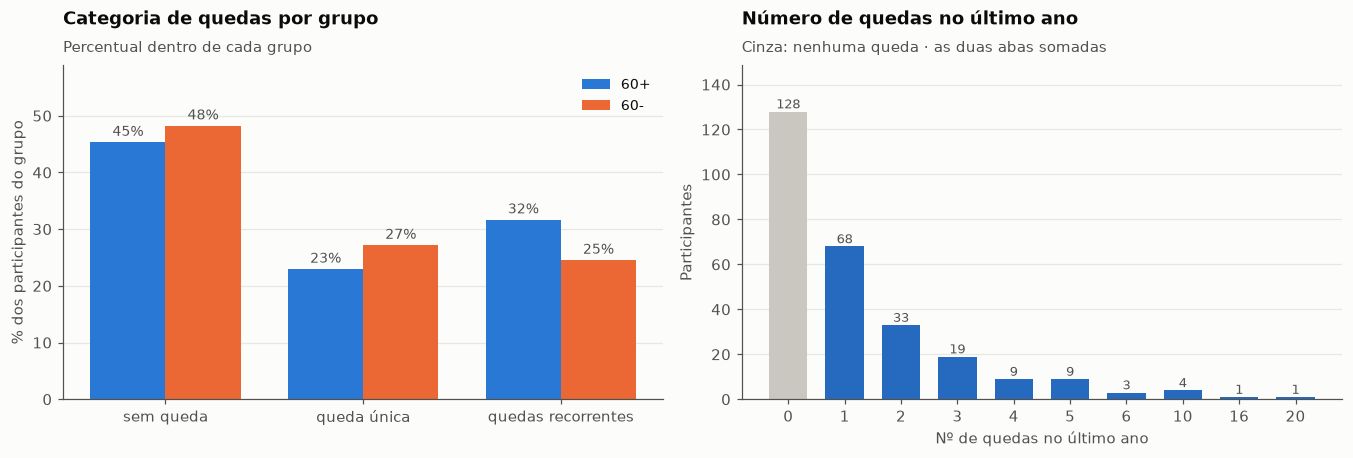

In [12]:
com_registro = base[base["n_quedas"].notna()]
tabela_pct = (pd.crosstab(com_registro["cat_quedas"], com_registro["grupo_origem"],
                          normalize="columns") * 100).reindex(FAIXAS_QUEDA)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
x = np.arange(len(FAIXAS_QUEDA))
largura = 0.38
for i, (grupo, cor) in enumerate(zip(ABAS, [AZUL, LARANJA])):
    valores = tabela_pct[grupo].values
    barras = ax.bar(x + (i - 0.5) * largura, valores, largura, color=cor, label=grupo)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.1, f"{v:.0f}%",
                ha="center", fontsize=9, color=TINTA2)
ax.set_xticks(x)
ax.set_xticklabels(FAIXAS_QUEDA)
ax.set_ylim(0, max(tabela_pct.max()) * 1.22)
ax.set_ylabel("% dos participantes do grupo")
ax.grid(axis="x", visible=False)
ax.text(0, 1.11, "Categoria de quedas por grupo", transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=TINTA, va="bottom")
ax.text(0, 1.03, "Percentual dentro de cada grupo", transform=ax.transAxes,
        fontsize=9.5, color=TINTA2, va="bottom")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
contagem_n = com_registro["n_quedas"].astype(int).value_counts().sort_index()
cores = [CINZA if k == 0 else AZUIS[4] for k in contagem_n.index]
barras = ax.bar(contagem_n.index.astype(str), contagem_n.values, color=cores, width=0.68)
for b, v in zip(barras, contagem_n.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.4, str(v),
            ha="center", fontsize=8.5, color=TINTA2)
ax.set_xlabel("Nº de quedas no último ano")
ax.set_ylabel("Participantes")
ax.set_ylim(0, contagem_n.max() * 1.16)
ax.grid(axis="x", visible=False)
ax.text(0, 1.11, "Número de quedas no último ano", transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=TINTA, va="bottom")
ax.text(0, 1.03, "Cinza: nenhuma queda · as duas abas somadas",
        transform=ax.transAxes, fontsize=9.5, color=TINTA2, va="bottom")

plt.tight_layout()
plt.show()

## 4. Custo da dupla tarefa (DTC)

### 4.1 Cálculo

$$\text{DTC}\,(\%) = \frac{\text{tarefa simples} - \text{dupla tarefa}}{\text{tarefa simples}} \times 100$$

Variável de desempenho: número de toques no BlazePod em 30 segundos. Como mais
toques indicam melhor desempenho, uma redução sob dupla tarefa produz DTC positivo.

In [13]:
base["reacao_simples_num"] = base["Reação (blazepod)"].apply(para_numero)
base["reacao_dupla_num"] = base["Reação (blazepod) DT"].apply(para_numero)

calculavel = (base["reacao_simples_num"].notna()
              & base["reacao_dupla_num"].notna()
              & (base["reacao_simples_num"] > 0))

base["dtc_pct"] = np.where(
    calculavel,
    (base["reacao_simples_num"] - base["reacao_dupla_num"])
    / base["reacao_simples_num"] * 100,
    np.nan).round(1)

print(f"DTC calculável em {int(calculavel.sum())} de {len(base)} participantes "
      f"({calculavel.mean() * 100:.1f}%)")
print()
motivos = pd.Series({
    "reação simples ausente": int(base["reacao_simples_num"].isna().sum()),
    "dupla tarefa ausente": int(base["reacao_dupla_num"].isna().sum()),
    "reação simples igual a zero": int((base["reacao_simples_num"] == 0).sum()),
})
print("Motivos de não cálculo:")
print(motivos.to_string())

DTC calculável em 267 de 282 participantes (94.7%)

Motivos de não cálculo:
reação simples ausente          7
dupla tarefa ausente           15
reação simples igual a zero     0


In [14]:
exemplo = base.loc[calculavel, ["chave", "reacao_simples_num", "reacao_dupla_num", "dtc_pct"]].head(5)
exemplo.columns = ["chave", "tarefa simples", "dupla tarefa", "DTC (%)"]
print("Conferência do cálculo em 5 participantes:\n")
exemplo

Conferência do cálculo em 5 participantes:



,chave,tarefa simples,dupla tarefa,DTC (%)
1,60+_002,40.0,18.0,55.0
2,60+_003,39.0,31.0,20.5
3,60+_004,33.0,19.0,42.4
4,60+_005,33.0,19.0,42.4
5,60+_006,43.0,18.0,58.1


In [15]:
def descritivas_dtc(df):
    linhas = []
    for nome in ABAS + ["total"]:
        sub = df if nome == "total" else df[df["grupo_origem"] == nome]
        d = sub["dtc_pct"].dropna()
        linhas.append({
            "grupo": nome,
            "n calculável": len(d),
            "média": round(d.mean(), 1),
            "mediana": round(d.median(), 1),
            "desvio padrão": round(d.std(), 1),
            "mínimo": round(d.min(), 1),
            "máximo": round(d.max(), 1),
            "DTC negativo (melhorou)": int((d < 0).sum()),
            "DTC acima de 50%": int((d > 50).sum()),
        })
    return pd.DataFrame(linhas).set_index("grupo")


descritivas_dtc(base)

,n calculável,média,mediana,desvio padrão,mínimo,máximo,DTC negativo (melhorou),DTC acima de 50%
grupo,,,,,,,,
60+,159,33.3,30.6,19.6,-13.9,81.0,4,35
60-,108,30.6,28.5,18.3,-16.0,75.0,2,17
total,267,32.2,29.4,19.1,-16.0,81.0,6,52


### 4.2 Gráfico

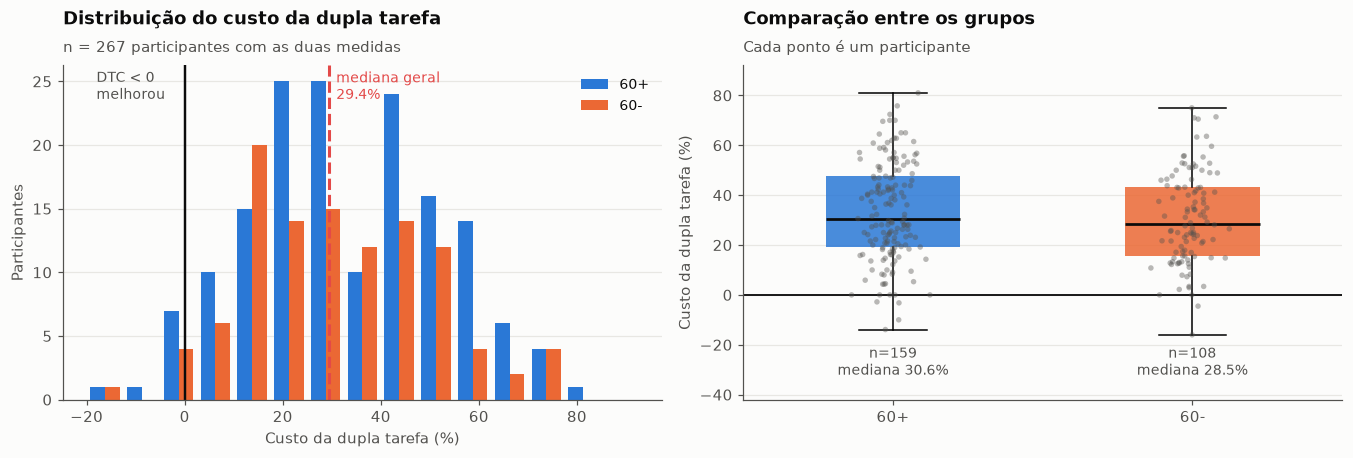

In [16]:
dtc_por_grupo = [base.loc[base["grupo_origem"] == nome, "dtc_pct"].dropna().values
                 for nome in ABAS]
todos = base["dtc_pct"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
bins = np.arange(-20, 95, 7.5)
ax.hist(dtc_por_grupo, bins=bins, color=[AZUL, LARANJA], label=ABAS)
ax.axvline(0, color=TINTA, linewidth=1.6)
ax.axvline(todos.median(), color=VERMELHO, linewidth=2, linestyle="--")
ax.text(todos.median() + 1.5, ax.get_ylim()[1] * 0.9,
        f"mediana geral\n{todos.median():.1f}%", color=VERMELHO, fontsize=9)
ax.text(-18, ax.get_ylim()[1] * 0.9, "DTC < 0\nmelhorou", fontsize=9, color=TINTA2)
ax.set_xlabel("Custo da dupla tarefa (%)")
ax.set_ylabel("Participantes")
ax.grid(axis="x", visible=False)
ax.text(0, 1.11, "Distribuição do custo da dupla tarefa", transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=TINTA, va="bottom")
ax.text(0, 1.03, f"n = {len(todos)} participantes com as duas medidas",
        transform=ax.transAxes, fontsize=9.5, color=TINTA2, va="bottom")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
caixas = ax.boxplot(dtc_por_grupo, patch_artist=True, widths=0.45,
                    medianprops=dict(color=TINTA, linewidth=1.8),
                    flierprops=dict(marker="o", markersize=4,
                                    markerfacecolor=CINZA, markeredgecolor="none"))
ax.set_xticks(range(1, len(ABAS) + 1))
ax.set_xticklabels(ABAS)
for caixa, cor in zip(caixas["boxes"], [AZUL, LARANJA]):
    caixa.set_facecolor(cor)
    caixa.set_alpha(0.85)
    caixa.set_edgecolor("none")
for i, valores in enumerate(dtc_por_grupo, start=1):
    espalha = np.random.default_rng(7).normal(i, 0.055, len(valores))
    ax.scatter(espalha, valores, s=13, color=TINTA2, alpha=0.4, edgecolor="none", zorder=3)
    ax.text(i, -32, f"n={len(valores)}\nmediana {np.median(valores):.1f}%",
            ha="center", fontsize=9, color=TINTA2)
ax.axhline(0, color=TINTA, linewidth=1.2)
ax.set_ylabel("Custo da dupla tarefa (%)")
ax.set_ylim(-42, 92)
ax.grid(axis="x", visible=False)
ax.text(0, 1.11, "Comparação entre os grupos", transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=TINTA, va="bottom")
ax.text(0, 1.03, "Cada ponto é um participante", transform=ax.transAxes,
        fontsize=9.5, color=TINTA2, va="bottom")

plt.tight_layout()
plt.show()

## 5. Conclusões parciais e dúvidas para a AACD

### O que os dados permitem concluir neste momento

A base está consolidada em 282 participantes (166 idosos e 116 adultos), com uma linha
por pessoa e chave única. O histórico de quedas está registrado em 97,0% dos idosos:
54,7% caíram ao menos uma vez no último ano e 31,7% caíram duas vezes ou mais, ou seja,
queda recorrente não é exceção e as três categorias devem ser analisadas separadamente.
O custo da dupla tarefa foi calculado em 94,7% da amostra, com mediana de 30,6% nos
idosos, o que indica perda de cerca de um terço do desempenho motor ao acrescentar uma
tarefa cognitiva. O preenchimento é desigual: 13 das 27 colunas passam de 95%, mas 7
ficam abaixo de 50%, e parte dessas lacunas é estrutural, como a panturrilha de quem tem
amputação. Os dados já descrevem a população e as quedas de forma confiável, mas ainda
não permitem afirmar associação entre os testes e o desfecho.

### Dúvidas para levar à equipe da AACD

**Sobre o desfecho**

1. Cinco participantes da aba 60+ e dois da 60− estão sem o número de quedas. O dado
   existe em outro registro ou devem sair da análise?
2. Dois participantes relatam 16 e 20 quedas no último ano. São valores confirmados?
3. A coluna "Queda último mês" está como número (0 e 2) nos IDs 22 a 29 da aba 60+, e
   como sim/não nos demais. Interpretamos 0 como "não caiu". A leitura está correta?

**Sobre a escala da CIF**

4. Em "CIF equilíbrio", 0 significa ausência de alteração ou o oposto? A direção da
   escala muda a interpretação de todos os cruzamentos.

**Sobre o teste de 10 metros**

5. Trinta e nove participantes identificados como cadeirantes têm tempo de 10 metros
   registrado. O trajeto foi percorrido andando ou na cadeira de rodas?
6. Um participante tem 1,2 segundos para 10 metros, o que equivale a 8,3 m/s. É erro
   de digitação? Qual o valor correto?
7. Oito participantes têm "NA" no teste sem indicação de uso de cadeira de rodas. O
   teste não foi realizado por outro motivo?

**Sobre os testes de força e antropometria**

8. Confirmamos que a ponte foi aplicada a quem não conseguia realizar o sentar e
   levantar, e vice-versa? Apenas um participante tem os dois testes.
9. A circunferência do braço foi usada como substituta da panturrilha em amputação e
   lesão medular. Dos 70 idosos sem panturrilha, apenas 13 têm o braço medido. Os
   outros 57 não foram medidos ou o dado está em outro lugar?
10. Dois participantes têm 0 kgf no dinamômetro. É força realmente ausente ou teste
    não realizado?

**Sobre cognição**

11. Dois participantes têm 11 e 12 pontos no 10-CS, acima do máximo de 10 do
    instrumento. Qual o valor correto?
12. A escolaridade dos participantes está registrada em algum outro lugar? As normas
    brasileiras do MoCA e do 10-CS exigem ajuste por escolaridade, e sem ela a
    interpretação dos escores fica limitada.

**Sobre elegibilidade e cadastro**

13. Sete participantes da aba 60+ têm menos de 60 anos, seis deles anotados com "?"
    (por exemplo "59?"). Permanecem no grupo de idosos ou mudam para a aba 60−?
14. Um participante da aba 60− tem a idade preenchida como "k". Qual a idade?
15. O "." em suporte social significa ausência de informação ou ausência de
    acompanhante?
16. "Polifarmácia" está em branco em 22 idosos. A pergunta não foi feita ou a resposta
    não foi anotada?
17. O BlazePod registra erros além do número de toques. Esses erros foram anotados em
    algum lugar?

## 6. Base consolidada

In [17]:
NOVAS_COLUNAS = ["chave", "grupo_origem", "n_quedas", "cat_quedas", "dtc_pct"]
base_consolidada = base[COLUNAS_ORIGINAIS + NOVAS_COLUNAS].copy()

base_consolidada.to_csv("base_consolidada.csv", index=False, encoding="utf-8")

print(f"Arquivo salvo: base_consolidada.csv")
print(f"Dimensões: {base_consolidada.shape[0]} linhas × {base_consolidada.shape[1]} colunas")
print(f"Colunas originais da planilha: {len(COLUNAS_ORIGINAIS)}")
print(f"Colunas novas: {NOVAS_COLUNAS}")

Arquivo salvo: base_consolidada.csv
Dimensões: 282 linhas × 32 colunas
Colunas originais da planilha: 27
Colunas novas: ['chave', 'grupo_origem', 'n_quedas', 'cat_quedas', 'dtc_pct']


In [18]:
assert len(base_consolidada) == 282
assert base_consolidada["chave"].is_unique
assert base_consolidada["chave"].notna().all()
for coluna in COLUNAS_ORIGINAIS:
    assert coluna in base_consolidada.columns, f"coluna original ausente: {coluna}"
for coluna in NOVAS_COLUNAS:
    assert coluna in base_consolidada.columns, f"coluna nova ausente: {coluna}"
assert set(base_consolidada["grupo_origem"].unique()) == set(ABAS)
assert set(base_consolidada["cat_quedas"].dropna().unique()) <= set(FAIXAS_QUEDA)
assert os.path.exists("base_consolidada.csv")

print("Verificações da entrega")
print(f"  uma linha por participante ................ {len(base_consolidada)} linhas")
print(f"  chave única ............................... ok")
print(f"  {len(COLUNAS_ORIGINAIS)} colunas originais preservadas ......... ok")
print(f"  5 colunas novas presentes ................. ok")
print(f"  n_quedas preenchida ....................... "
      f"{int(base_consolidada['n_quedas'].notna().sum())}/282")
print(f"  cat_quedas preenchida ..................... "
      f"{int(base_consolidada['cat_quedas'].notna().sum())}/282")
print(f"  dtc_pct preenchida ........................ "
      f"{int(base_consolidada['dtc_pct'].notna().sum())}/282")
print(f"  arquivo gravado em disco .................. ok")

Verificações da entrega
  uma linha por participante ................ 282 linhas
  chave única ............................... ok
  27 colunas originais preservadas ......... ok
  5 colunas novas presentes ................. ok
  n_quedas preenchida ....................... 275/282
  cat_quedas preenchida ..................... 275/282
  dtc_pct preenchida ........................ 267/282
  arquivo gravado em disco .................. ok


In [19]:
pd.read_csv("base_consolidada.csv")[
    ["chave", "grupo_origem", "Sexo", "Idade", "Clínica/Dx",
     "Nº quedas ao chão", "n_quedas", "cat_quedas", "dtc_pct"]].head(10)

,chave,grupo_origem,Sexo,Idade,Clínica/Dx,Nº quedas ao chão,n_quedas,cat_quedas,dtc_pct
0,60+_001,60+,M,68,LEA,4,4.0,quedas recorrentes,NaN
1,60+_002,60+,M,72,AMP,0,0.0,sem queda,55.0
2,60+_003,60+,F,77,Parkison,0,0.0,sem queda,20.5
3,60+_004,60+,M,62,AMP,1,1.0,queda única,42.4
4,60+_005,60+,F,62,DNM,2,2.0,quedas recorrentes,42.4
5,60+_006,60+,F,66,Polio?,1,1.0,queda única,58.1
6,60+_007,60+,F,69,LEA,2,2.0,quedas recorrentes,32.3
7,60+_008,60+,M,73,AMP,3,3.0,quedas recorrentes,21.4
8,60+_009,60+,M,60,LEA,0,0.0,sem queda,56.2
9,60+_010,60+,M,60,LEA,1,1.0,queda única,NaN
